1. Given a small dataset of 2D points representing food delivery locations (e.g., [2,3], [5,8], [1,2], [6,9], [7,7]), plot the points on graph paper or using matplotlib, randomly pick two initial centroids, and manually assign each point to the nearest centroid using Euclidean distance.
|

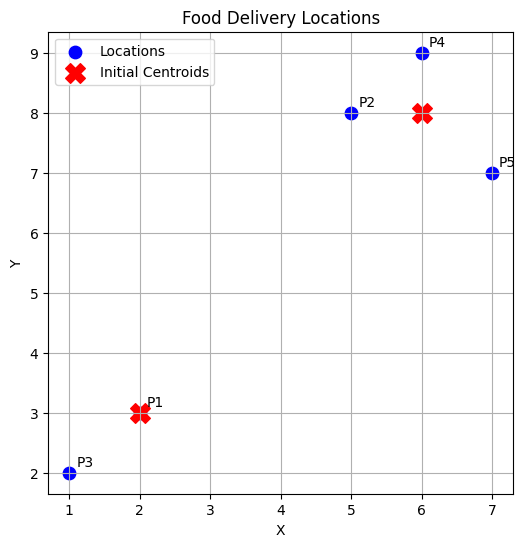

In [1]:
import matplotlib.pyplot as plt
import numpy as np

points = np.array([
    [2,3],
    [5,8],
    [1,2],
    [6,9],
    [7,7]
])

centroids = np.array([
    [2,3],
    [6,8]
])

plt.figure(figsize=(6,6))

plt.scatter(points[:,0], points[:,1],
            color='blue', s=80, label='Locations')

plt.scatter(centroids[:,0], centroids[:,1],
            color='red', marker='X', s=200,
            label='Initial Centroids')

for i, point in enumerate(points):
    plt.text(point[0]+0.1, point[1]+0.1, f"P{i+1}")

plt.title("Food Delivery Locations")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()

2. Write a Python function assign_clusters(points, centroids) that takes a list of points and a list of centroids, and returns a list showing which cluster each point belongs to using Euclidean distance.


In [2]:
import numpy as np

def assign_clusters(points, centroids):

    assignments = []

    for point in points:

        distances = [
            np.linalg.norm(point-centroid)
            for centroid in centroids
        ]

        cluster = np.argmin(distances)

        assignments.append(cluster)

    return assignments


points = np.array([
    [2,3],
    [5,8],
    [1,2],
    [6,9],
    [7,7]
])

centroids = np.array([
    [2,3],
    [6,8]
])

print(assign_clusters(points, centroids))

[np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1)]


3. Update your assign_clusters code to work with Manhattan distance as well. Allow the user to choose between 'euclidean' and 'manhattan' as a parameter.


In [3]:
import numpy as np

def assign_clusters(points, centroids, metric="euclidean"):

    assignments = []

    for point in points:

        distances = []

        for centroid in centroids:

            if metric == "euclidean":

                distance = np.linalg.norm(point-centroid)

            elif metric == "manhattan":

                distance = np.sum(np.abs(point-centroid))

            else:

                raise ValueError("Invalid metric")

            distances.append(distance)

        assignments.append(np.argmin(distances))

    return assignments


print("Euclidean")

print(assign_clusters(points, centroids, "euclidean"))

print()

print("Manhattan")

print(assign_clusters(points, centroids, "manhattan"))

Euclidean
[np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1)]

Manhattan
[np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1)]


4. Implement a function update_centroids(points, assignments, k) that calculates the new centroid for each cluster as the mean of the assigned points. Test it with a sample dataset of your choice.


In [4]:
import numpy as np

def update_centroids(points, assignments, k):

    centroids = []

    for cluster in range(k):

        cluster_points = points[
            np.array(assignments) == cluster
        ]

        centroid = cluster_points.mean(axis=0)

        centroids.append(centroid)

    return np.array(centroids)


assignments = [0,1,0,1,1]

new_centroids = update_centroids(
    points,
    assignments,
    k=2
)

print(new_centroids)

[[1.5 2.5]
 [6.  8. ]]


5. Use the Elbow Method to determine the optimal number of clusters (k) for a dataset of your choice (e.g., favorite songs by tempo and danceability, or Zomato restaurant ratings and price). Plot the within-cluster sum of squares for k=1 to k=6 and identify the 'elbow' point.<br><br><em><strong>Hint:</strong> Use sklearn's KMeans and matplotlib for plotting.</em>

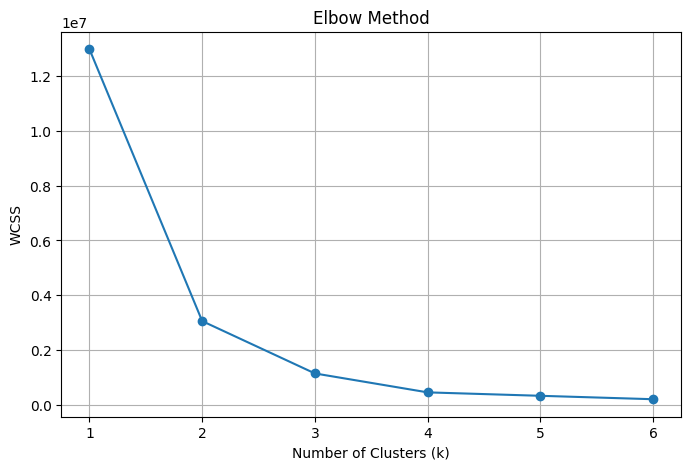

WCSS Values
k=1: 12981001.50
k=2: 3058333.85
k=3: 1147500.20
k=4: 456666.84
k=5: 331666.82
k=6: 206666.81


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.DataFrame({

    "price":[500,700,900,1500,1700,2000,
             2500,3000,3500,4000],

    "rating":[3.5,3.8,4.0,4.1,4.2,
              4.3,4.4,4.6,4.7,4.8]

})

X = df[["price","rating"]]

wcss = []

for k in range(1,7):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X)

    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,7),
    wcss,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters (k)")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

print("WCSS Values")

for i, value in enumerate(wcss, start=1):
    print(f"k={i}: {value:.2f}")